# Supercritical CO₂ Power Cycle

The model is implemented as a subclass of
[TESPy](https://github.com/oemof/tespy)'s `ModelTemplate` in
[sCO2.py](./sCO2.py), the exergy analysis is carried out with
[exerpy](https://github.com/oemof/exerpy).

Original data from: *M. Penkuhn, G. Tsatsaronis, Exergoeconomic analyses of
different sCO2 cycle configurations, 6th International Symposium — Supercritical
CO2 Power Cycles, 2018.*

In [ ]:
from sCO2 import SCO2Model

model = SCO2Model()
model.nw.iterinfo = False
model.solve_design()

## Cycle diagrams

The cycle operates entirely above the critical pressure of CO₂ as seen in the
following two cycle diagrams.

Note, that `SCO2Model` overrides the `create_diagram` method to extend the
temperature and pressure isoline ranges to the operating envelope of the
cycle. QT diagrams of the recuperators are available via
`plot_QT_diagram_matplotlib`, but they are not particularly relevant in this
model.

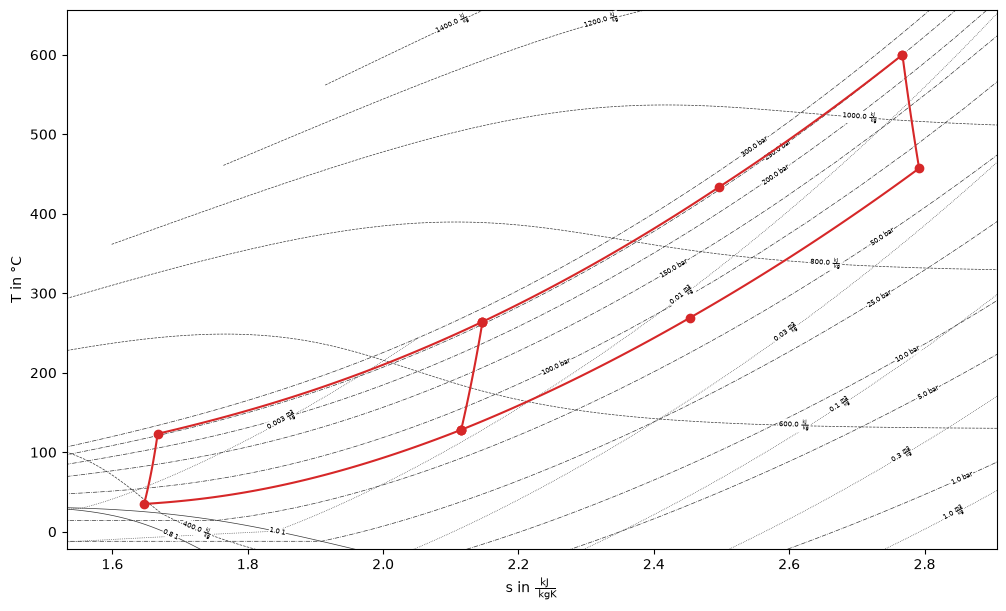

In [ ]:
fig, ax = model.plot_Ts_diagram_matplotlib("01", figsize=(12, 7))

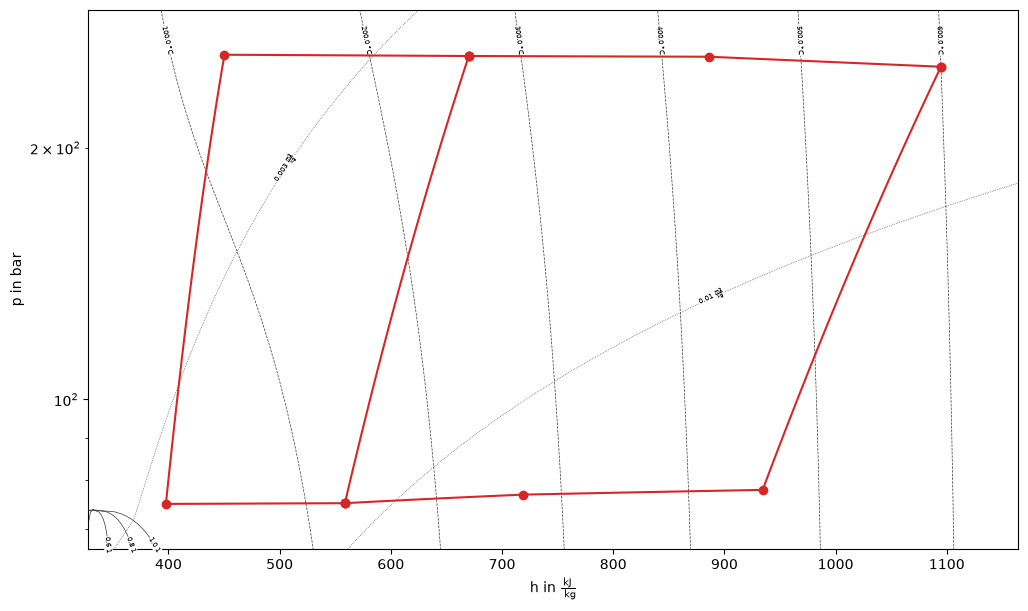

In [ ]:
fig, ax = model.plot_logph_diagram_matplotlib("01", figsize=(12, 7))

## Validation

The exergy analysis takes the heat input as fuel and the net power delivered to
the grid as product. The validation compares connection states and component
exergy balances against the publication data. Motor and generator efficiencies
are lumped into the turbomachines.

In [ ]:
from sCO2 import validate

ean = model.run_exergy_analysis()
validate(model)

,E_F,E_P,E_D
Component,,,
CMP,-0.002712,-0.001213,-0.003523
Compressor 1,-0.002268,-0.000037,-0.000885
Compressor 2,-0.003272,-0.002650,-0.007535
Heater,-0.019426,-0.006494,-0.711113
REC,-0.000476,-0.000189,0.004904
Recuperator 1,-0.001223,-0.000930,-0.006468
Recuperator 2,-0.000080,0.000194,-0.009869
Turbine,-0.001054,-0.001248,-0.006298


*The high deviation in the heater E_D is due to differences in the component
exergy balance definitions, see the [README](./README.md).*

In [ ]:
df_components, df_connections, df_power = ean.exergy_results(print_results=False)
df_components

,Component,E_F [kW],E_P [kW],E_D [kW],E_L [kW],epsilon [%],y [%],y* [%]
0,Compressor 1,45145.931335,40198.500484,4947.430851,0.0,89.041248,3.193320,9.006691
1,Compressor 2,35720.359985,32812.816435,2907.543550,0.0,91.860262,1.876675,5.293120
2,Heater,154930.614659,154092.841924,837.772734,0.0,99.459259,0.540741,1.525147
4,Merge 1,0.000000,0.000000,0.000000,0.0,NaN,0.000000,0.000000
5,Recuperator 1,73809.653840,69934.880594,3874.773245,0.0,94.750316,2.500973,7.053941
6,Recuperator 2,139188.806739,135426.310109,3762.496630,0.0,97.296840,2.428504,6.849544
7,Splitter 1,NaN,NaN,0.000000,0.0,NaN,0.000000,0.000000
8,Turbine,197191.844625,188826.328257,8365.516367,0.0,95.757676,5.399524,15.229242
3,Water cooler,22275.044344,NaN,22275.044344,0.0,NaN,14.377432,40.551238
9,generator,188826.328257,185068.684325,3757.643932,0.0,98.010000,2.425372,6.840710


## Using the model for your own analyses

You can use this model for own analyses if you are interested. All interaction
happens through named parameters, which are defined in the `_parameter_lookup`
method of the `SCO2Model` class. Find more information on setting these up in
the documentation of tespy.

To adjust the model for your own analysis, extend that dictionary with the
connections or components you are interested in, for example:

```python
"recuperator 1 terminal temperature": ["Components", "Recuperator 1", "ttd_l"],
```

These are the parameters currently defined:

In [ ]:
list(model.parameter_lookup)

['net power',
 'heat input',
 'turbine inlet temperature',
 'turbine inlet pressure',
 'compressor inlet temperature',
 'compressor inlet pressure',
 'turbine efficiency',
 'thermal efficiency']

### Retrieving results

Read a single value with `get_parameter` or several at once with
`get_results`:

In [ ]:
import pandas as pd


pd.Series(model.get_results(list(model.parameter_lookup)))

net power                       100.000000
heat input                      245.974293
turbine inlet temperature       600.000000
turbine inlet pressure          250.000000
compressor inlet temperature     35.000000
compressor inlet pressure        75.000000
turbine efficiency                0.900000
thermal efficiency                0.406547
dtype: float64

### Solving with an updated input

`solve_model` sets the given parameters and solves the model.

In [ ]:
model.solve_model(**{"turbine inlet temperature": 620})
round(model.get_parameter("thermal efficiency"), 4)

0.4176

### Sensitivity analysis

`sensitivity_analysis` solves the model for each value of an input parameter
list and logs the values of the respective results specified in the result
parameter list.

In [ ]:
df = model.sensitivity_analysis(
    param_dict={"turbine inlet temperature": [550.0, 575.0, 600.0, 625.0, 650.0]},
    result_param_list=["thermal efficiency", "heat input"],
)
df

,turbine inlet temperature,thermal efficiency,heat input
0,550.0,0.376638,265.506865
1,575.0,0.392031,255.082066
2,600.0,0.406547,245.974293
3,625.0,0.420268,237.943326
4,650.0,0.433267,230.804602


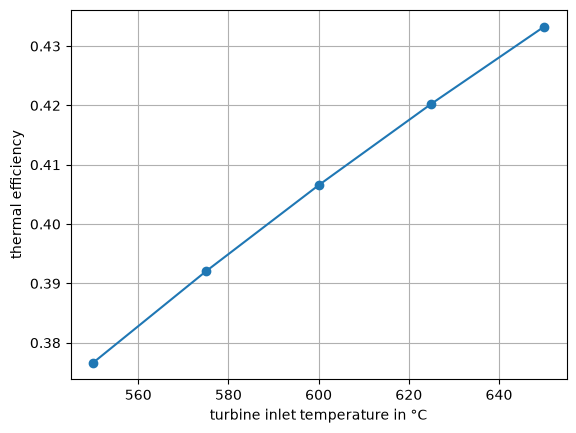

In [ ]:
ax = df.set_index("turbine inlet temperature")["thermal efficiency"].plot(
    marker="o", grid=True,
    xlabel="turbine inlet temperature in °C", ylabel="thermal efficiency",
)

# restore the nominal state
model.solve_model(**{"turbine inlet temperature": 600})